In [1725]:
%matplotlib inline

In [1726]:
import re

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Mental disorders analysis

## Introduction

Nowadays, more and more people experience mental health disorders. For some, the symptoms improve over time without treatment, while others need professional therapy and support. Mental disorders can affect anyone, often triggered by factors we least expect. The most common conditions include Depression and Anxiety, while Obsessive Compulsive Disorder (OCD) is less frequent but still significant.

In this project, I will explore these disorders through three different datasets, aiming to answer important questions and better understand their patterns and impact.

## Plan
Although the project title is *Mental disorders analysis*, we are going to analyze only a few like depression, anxiety and Obsessive Compulsive Disorder.

At the beginning we are going to clean and explore the datasets.

Then we will proceed to make some hypothesis and prove or reject them.

After that will try to train a model using Multiple Linear Regression that will try to predict what level of anxiety (1-10) a person has.

## Data Sources and Limitations
Two of the three datasets used in this project are synthetic:
- The **Enhanced Anxiety Dataset** is described by its author as synthetic, crafted to reflect real-world behavioral and psychological patterns. However, its description contains a contradiction, also claiming to be compiled from real-world survey responses. The true origin is therefore uncertain.

- The **OCD Patient Dataset** is explicitly fictional, generated by its author for educational and research purposes only.

- The **Student Depression Dataset** source has not explicitly stated whether it is synthetic or real.

## Data Cleanup

Let's begin by creating a function that will be used for renaming columns to *snake_case*

In [1727]:
def to_snake_case(col_name):
    col_name = col_name.strip()
    col_name = col_name.lower()
    col_name = re.sub(r"[^\w\s]", "_", col_name) # replace non-alphanumeric characters with underscores
    col_name = re.sub(r"\s+", "_", col_name) # regex is used instead of replace to handle multiple spaces
    col_name = re.sub(r"_+", "_", col_name)  # replace multiple underscores with a single underscore
    col_name = col_name.rstrip("_")

    return col_name

Because we will mostly work with numerical data, we need a way to represent categorical data as integers.

In [1728]:
# val1 and val2 are case insensitive and default to "yes" and "no"
def binary_encode(df, column, val1 = "yes", val2 = "no"):
    df[column] = df[column].str.lower().map({val1.lower(): 1, val2.lower(): 0})

In [1729]:
# nominal encoding using OneHotEncoder
def one_hot_encode(df, column):
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
    ohetransform = ohe.fit_transform(df[[column]])
    df = pd.concat([df, ohetransform], axis=1).drop(column, axis=1)
    
    df.columns = [to_snake_case(c) for c in df.columns]

    return df

In [1730]:
def ordinal_encode(df, column, categories_order):
    # Transform both the list and the column to lowercase for consistency and case insensitivity
    categories_order_lower = [cat.lower() for cat in categories_order]
    df[column] = df[column].str.lower()

    encoder = OrdinalEncoder(categories=[categories_order_lower])
    df[column] = encoder.fit_transform(df[[column]])

The following plotting functions will be used throughout the Data Cleanup section.

In [1731]:
def plot_category_counts(df, column_name, title=None, xlabel=None, ylabel="Count"):
    category_stats = df[column_name].value_counts()
    
    categories = category_stats.index
    counts = category_stats.values

    plt.bar(categories, counts)
    plt.title(title if title else f"Students by {column_name}")
    plt.xlabel(xlabel if xlabel else column_name)
    plt.ylabel(ylabel)

    for i, count in enumerate(counts):
        plt.text(i, count, str(count), ha="center", va="bottom")

    plt.show()

### Student Depression

Let's start with the Student Depression Dataset.csv dataset.

In [1732]:
student_depression_data = pd.read_csv("data/Student Depression Dataset.csv")

In [1733]:
student_depression_data

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [1734]:
student_depression_data.columns = [to_snake_case(c) for c in student_depression_data.columns]

First thing we notice is that there is a column *id* which we need to check for uniqueness

In [1735]:
student_depression_data.id.nunique() == len(student_depression_data)

True

Since it has no repetitions we can safely remove the column

In [1736]:
student_depression_data = student_depression_data.drop(columns=["id"])

First thing we notice is that the dataset contains a column named Profession. However, that column includes Student as a value. We also have Work/Study Hours.

In [1737]:
profession_stats = student_depression_data.profession.value_counts()
profession_stats.columns = ["Profession", "Count"]
profession_stats

profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

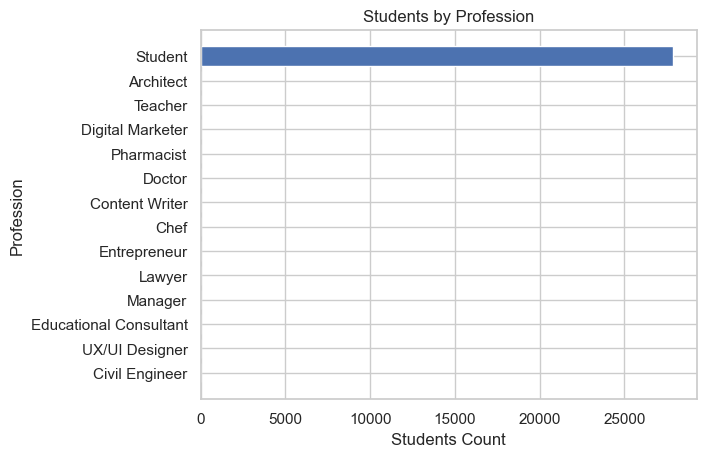

In [1738]:
profession_stats = student_depression_data["profession"].value_counts(ascending=True)

professions = profession_stats.index
counts = profession_stats.values

# Horizontal bar chart so that profession names are fully visible
plt.barh(professions, counts)
plt.title("Students by Profession")
plt.xlabel("Students Count")
plt.ylabel("Profession")

plt.show()

As the name of the dataset suggests, it is about students. Data also shows it by having too little of the remaining values. That is why I am going to assume that any other profession is not usable for any hypotheses and any row that is not a student will be considered to be an outlier and therefore be removed.

In [1739]:
student_depression_data = student_depression_data[student_depression_data.profession == "Student"]

Let's not forget to rename the Work/Study Hours (that now is work_study_hours) since it would not make sense otherwise

In [1740]:
student_depression_data = student_depression_data.rename(columns={"work_study_hours": "study_hours"})

We can also see that there are very few students that have a value for the column Job Satisfaction. However, the profession is Student. These students could either be studying and working or only studying but since the value in the previously named column Work/Job Hours was in one place, I will assume that this data is redundant and could be deleted.

In [1741]:
student_depression_data.job_satisfaction.value_counts()

job_satisfaction
0.0    27862
2.0        3
4.0        2
1.0        2
3.0        1
Name: count, dtype: int64

In [1742]:
student_depression_data = student_depression_data[student_depression_data.job_satisfaction == 0]
student_depression_data = student_depression_data.drop(columns=["job_satisfaction"])

Here we can see that there are different values for **Work Pressure** and since we already decided to test only for students that are not employed, we am going to drop that column.

In [1743]:
student_depression_data.work_pressure.value_counts()

work_pressure
0.0    27862
Name: count, dtype: int64

In [1744]:
student_depression_data = student_depression_data.drop(columns=["work_pressure"])

Since we removed all records where the Profession column has a value different than Student we can remove the whole column since it does not bring any new knowledge

In [1745]:
student_depression_data = student_depression_data.drop(columns=["profession"])

Now in order to be more consistent I will translate the values of the following columns to 0 and 1 instead of Yes or No:

Have you ever had suicidal thoughts ?

Family History of Mental Illness

And the gender column to: Male = 0 and Female = 1

But let's first see if there are values that are not Yes or No and not Male or Female.

In [1746]:
print(student_depression_data.gender.unique())
print(student_depression_data.have_you_ever_had_suicidal_thoughts.unique())
print(student_depression_data.family_history_of_mental_illness.unique())

['Male' 'Female']
['Yes' 'No']
['No' 'Yes']


I encode male and female as 0 and 1 because there aren't other values and I assume such won't be added

In [1747]:
binary_encode(student_depression_data, "have_you_ever_had_suicidal_thoughts")
binary_encode(student_depression_data, "family_history_of_mental_illness")
binary_encode(student_depression_data, "gender", "Male", "Female")

We have some ordinal categorical values that must be converted to numerical

I've picked *sleep_duration* and *dietary_habits* because both can be ordered incrementally.

Let's begin with *dietary_habits*.

First we need to see all possible values and order them incrementally.

In [1748]:
student_depression_data.dietary_habits.unique()

array(['Healthy', 'Moderate', 'Unhealthy', 'Others'], dtype=object)

As we can see, we have four unique values. It is easy to order them from least to most harmful: Healthy (0) $ \rightarrow $ Moderate (1) $ \rightarrow $ Unhealthy (2). I choose this order because of the semantics of the dataset. Because the dataset is about depression, it is logical *Healthy* to be the lowest.

However, there is a slight problem. There is also a *Others* value. What should we do with it?

In [1749]:
student_depression_data.dietary_habits.value_counts()

dietary_habits
Unhealthy    10307
Moderate      9905
Healthy       7638
Others          12
Name: count, dtype: int64

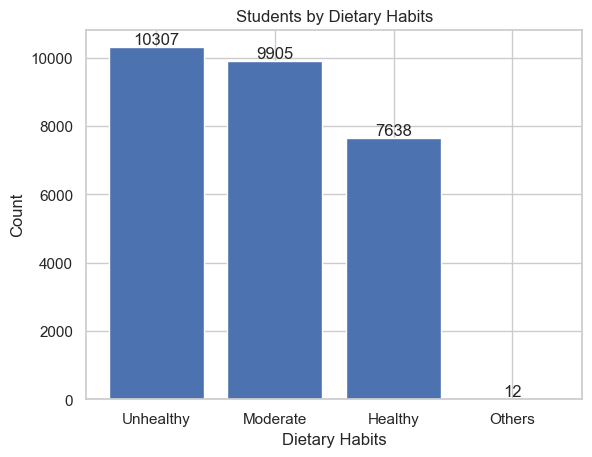

In [1750]:
plot_category_counts(student_depression_data, "dietary_habits", title="Students by Dietary Habits", xlabel="Dietary Habits")

As we can see the case with the value *Others* is similar to the *profession* column we removed. It brings little to no entropy and we can just remove those values.

In [1751]:
student_depression_data = student_depression_data[student_depression_data.dietary_habits != "Others"]

And we can finally convert the ordinal values to numerical using the *ordinal_encode* function.

In [1752]:
student_depression_data.sleep_duration.unique()

array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
       'Others'], dtype=object)

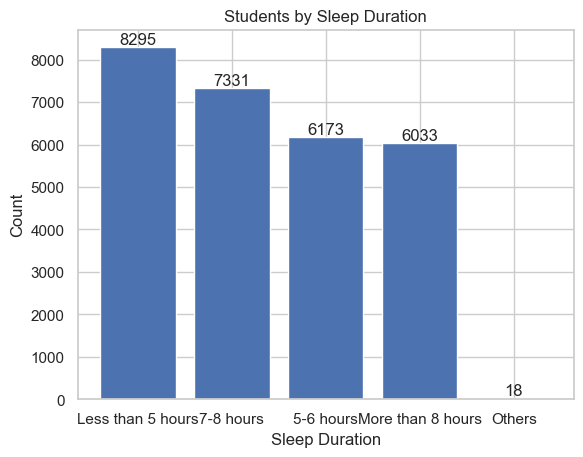

In [1753]:
plot_category_counts(student_depression_data, "sleep_duration", title="Students by Sleep Duration", xlabel="Sleep Duration")

As we can see the situation of *sleep_duration* is similar to that of *dietary_habits* so we can again delete rows where the value is *Others*

In [1754]:
student_depression_data = student_depression_data[student_depression_data.sleep_duration != "Others"]

In [1755]:
ordinal_encode(student_depression_data, "dietary_habits", ["Healthy", "Moderate", "Unhealthy"])
ordinal_encode(student_depression_data, "sleep_duration", ["More than 8 hours", "7-8 hours", "5-6 hours", "Less than 5 hours"])

Now, let's check if there are other than 1 and 0 in the depression column

In [1756]:
student_depression_data.depression.value_counts()

depression
1    16287
0    11545
Name: count, dtype: int64

Finally, let's do something about **city** and **degree**

In [1757]:
print("Degrees:", student_depression_data.degree.nunique(), student_depression_data.degree.unique())
print("Cities:", student_depression_data.city.nunique(), student_depression_data.city.unique())

Degrees: 28 ['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' 'Class 12' 'B.Ed' 'LLB' 'BE'
 'M.Ed' 'MSc' 'BHM' 'M.Pharm' 'MCA' 'MA' 'B.Com' 'MD' 'MBA' 'MBBS' 'M.Com'
 'B.Arch' 'LLM' 'B.Tech' 'BBA' 'ME' 'MHM' 'Others']
Cities: 52 ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']


As we can see, there are a lot of unique values. One way to encode the data is by first grouping the **degree** and **city** into more general categories.

In [1758]:
student_depression_data["degree"] = student_depression_data["degree"].str.strip()

In [1759]:
degree_mapping = {
    # School
    "Class 12": "School",
    # Undergrad
    "B.Pharm": "Undergrad", "BSc": "Undergrad", "BA": "Undergrad", "BCA": "Undergrad",
    "LLB": "Undergrad", "BE": "Undergrad", "BHM": "Undergrad", "B.Com": "Undergrad",
    "B.Arch": "Undergrad", "B.Tech": "Undergrad", "BBA": "Undergrad", "B.Ed": "Undergrad",
    # Postgrad
    "M.Tech": "Postgrad", "M.Ed": "Postgrad", "MSc": "Postgrad", "M.Pharm": "Postgrad",
    "MCA": "Postgrad", "MA": "Postgrad", "M.Com": "Postgrad", "LLM": "Postgrad",
    "ME": "Postgrad", "MHM": "Postgrad", "MBA": "Postgrad",
    # Doctorate
    "PhD": "Doctorate", "MD": "Doctorate", "MBBS": "Doctorate",
    # Others
    "Others": "Others"
}

In [1760]:
student_depression_data["degree"] = student_depression_data["degree"].map(degree_mapping).fillna("Others")

In [1761]:
student_depression_data.value_counts("degree")

degree
Undergrad    12607
Postgrad      7335
School        6073
Doctorate     1782
Others          35
Name: count, dtype: int64

In [1762]:
student_depression_data = student_depression_data[student_depression_data["degree"] != "Others"]

In [1763]:
ordinal_encode(student_depression_data, "degree", ["School", "Undergrad", "Postgrad", "Doctorate"])

Now for the cities, let's first remove the invalid city names.

In [1764]:
valid_cities = [
    "Visakhapatnam", "Bangalore", "Srinagar", "Varanasi", "Jaipur", "Pune",
    "Thane", "Chennai", "Nagpur", "Nashik", "Vadodara", "Kalyan", "Rajkot",
    "Ahmedabad", "Kolkata", "Mumbai", "Lucknow", "Indore", "Surat",
    "Ludhiana", "Bhopal", "Meerut", "Agra", "Ghaziabad", "Hyderabad",
    "Vasai-Virar", "Kanpur", "Patna", "Faridabad", "Delhi", "Khaziabad"
]

In [1765]:
invalid_data = student_depression_data[~student_depression_data["city"].isin(valid_cities)]

In [1766]:
print("Total invalid records:", len(invalid_data))
print(invalid_data['city'].value_counts())

Total invalid records: 25
city
Saanvi                2
Bhavna                2
City                  2
Harsha                2
M.Tech                1
Less Delhi            1
3.0                   1
Less than 5 Kalyan    1
Mira                  1
Vaanya                1
Gaurav                1
Harsh                 1
Reyansh               1
Kibara                1
Rashi                 1
ME                    1
M.Com                 1
Nalyan                1
Mihir                 1
Nalini                1
Nandini               1
Name: count, dtype: int64


In [1767]:
student_depression_data = student_depression_data[student_depression_data["city"].isin(valid_cities)]

In [1768]:
print(f"Remaining records after cleaning: {len(student_depression_data)}")

Remaining records after cleaning: 27772


And now, group the cities by urbanization.

In [1769]:
city_size_mapping = {
    # Megapolis
    "Delhi": "Megapolis", "Mumbai": "Megapolis", "Kolkata": "Megapolis",
    "Bangalore": "Megapolis", "Chennai": "Megapolis", "Hyderabad": "Megapolis",
    "Ahmedabad": "Megapolis",
    # City
    "Pune": "City", "Surat": "City", "Jaipur": "City", "Lucknow": "City",
    "Kanpur": "City", "Nagpur": "City", "Visakhapatnam": "City",
    "Indore": "City", "Patna": "City", "Bhopal": "City", "Thane": "City",
    "Ludhiana": "City", "Rajkot": "City", "Vadodara": "City",
    # Town
    "Agra": "Town", "Varanasi": "Town", "Meerut": "Town",
    "Faridabad": "Town", "Nashik": "Town", "Kalyan": "Town",
    "Vasai-Virar": "Town", "Srinagar": "Town", "Ghaziabad": "Town",
    "Khaziabad": "Town"
}

In [1770]:
student_depression_data["city"] = student_depression_data["city"].map(city_size_mapping)

In [1771]:
ordinal_encode(student_depression_data, "city", ["Town", "City", "Megapolis"])

This is what the dataset looks like after the cleanup

In [1772]:
student_depression_data

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts,study_hours,financial_stress,family_history_of_mental_illness,depression
0,1,33.0,1.0,5.0,8.97,2.0,2.0,0.0,1.0,1,3.0,1.0,0,1
1,0,24.0,2.0,2.0,5.90,5.0,2.0,1.0,1.0,0,3.0,2.0,1,0
2,1,31.0,0.0,3.0,7.03,5.0,3.0,0.0,1.0,0,9.0,1.0,1,0
3,0,28.0,0.0,3.0,5.59,2.0,1.0,1.0,1.0,1,4.0,5.0,1,1
4,0,25.0,1.0,4.0,8.13,3.0,2.0,1.0,2.0,1,1.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,27.0,1.0,5.0,5.75,5.0,2.0,2.0,0.0,1,7.0,1.0,1,0
27897,1,27.0,1.0,2.0,9.40,3.0,3.0,0.0,2.0,0,0.0,3.0,1,0
27898,1,31.0,0.0,3.0,6.61,4.0,2.0,2.0,3.0,0,12.0,2.0,0,0
27899,0,18.0,1.0,5.0,6.88,2.0,3.0,0.0,0.0,1,10.0,5.0,0,1


The dataset looks good. Let's now proceed with the second dataset that is about anxiety.

### Enhanced Anxiety

In [1773]:
enhanced_anxiety_data = pd.read_csv("data/enhanced_anxiety_dataset.csv")

In [1774]:
enhanced_anxiety_data

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,Female,Engineer,6.1,3.1,566,9,Yes,No,8,91,28,1,Yes,Yes,1,No,3,6.0
10996,50,Other,Teacher,6.6,3.6,64,17,Yes,No,7,95,17,3,No,No,2,No,7,3.0
10997,29,Male,Nurse,6.7,6.9,159,14,No,No,8,72,16,1,Yes,Yes,2,Yes,7,4.0
10998,53,Other,Artist,5.7,2.7,248,8,No,No,4,112,28,3,Yes,Yes,1,Yes,2,4.0


In [1775]:
enhanced_anxiety_data.columns = [to_snake_case(c) for c in enhanced_anxiety_data.columns]

In [1776]:
print(f"smoking => {enhanced_anxiety_data.smoking.unique()}")
print(f"family_history_of_anxiety => {enhanced_anxiety_data.family_history_of_anxiety.unique()}")
print(f"dizziness => {enhanced_anxiety_data.dizziness.unique()}")
print(f"medication => {enhanced_anxiety_data.medication.unique()}")
print(f"recent_major_life_event => {enhanced_anxiety_data.recent_major_life_event.unique()}")

smoking => ['Yes' 'No']
family_history_of_anxiety => ['No' 'Yes']
dizziness => ['No' 'Yes']
medication => ['Yes' 'No']
recent_major_life_event => ['Yes' 'No']


In [1777]:
binary_encode(enhanced_anxiety_data, "smoking")
binary_encode(enhanced_anxiety_data, "family_history_of_anxiety")
binary_encode(enhanced_anxiety_data, "dizziness")
binary_encode(enhanced_anxiety_data, "medication")
binary_encode(enhanced_anxiety_data, "recent_major_life_event")

In [1778]:
print(f"gender => {enhanced_anxiety_data.gender.unique()}")

gender => ['Female' 'Other' 'Male']


We can notice that in this dataset, exist records whose gender is *other*.

Let's check the distribution of the column so we know what to do with those rows.

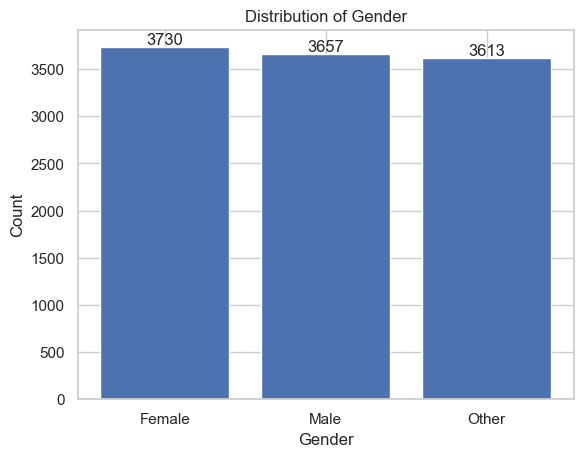

In [1779]:
plot_category_counts(enhanced_anxiety_data, "gender", title="Distribution of Gender", xlabel="Gender")

As we can see we have roughly an uniform distribution of the gender columns and having it removed will make a great bias.

Having said that, the *gender* column's type is no longer binary but nominal.

Therefore, *one-hot-encoding* is the appropriate method to represent it as numbers without creating artificial order.

In [1780]:
enhanced_anxiety_data = one_hot_encode(enhanced_anxiety_data, "gender")

We can use the same strategy for the **occupation** column.

In [1781]:
enhanced_anxiety_data.occupation.unique()

array(['Artist', 'Nurse', 'Other', 'Scientist', 'Lawyer', 'Teacher',
       'Doctor', 'Musician', 'Student', 'Engineer', 'Freelancer', 'Chef',
       'Athlete'], dtype=object)

In [1782]:
enhanced_anxiety_data = one_hot_encode(enhanced_anxiety_data, "occupation")

In [1783]:
enhanced_anxiety_data

,age,sleep_hours,physical_activity_hrs_week,caffeine_intake_mg_day,alcohol_consumption_drinks_week,smoking,family_history_of_anxiety,stress_level_1_10,heart_rate_bpm,breathing_rate_breaths_min,...,occupation_doctor,occupation_engineer,occupation_freelancer,occupation_lawyer,occupation_musician,occupation_nurse,occupation_other,occupation_scientist,occupation_student,occupation_teacher
0,29,6.0,2.7,181,10,1,0,10,114,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46,6.2,5.7,200,8,1,1,1,62,23,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,64,5.0,3.7,117,4,0,1,1,91,28,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,20,5.8,2.8,360,6,1,0,4,86,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,49,8.2,2.3,247,4,1,0,1,98,19,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,6.1,3.1,566,9,1,0,8,91,28,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10996,50,6.6,3.6,64,17,1,0,7,95,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10997,29,6.7,6.9,159,14,0,0,8,72,16,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10998,53,5.7,2.7,248,8,0,0,4,112,28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Ocd Patient Dataset

In [1784]:
ocd_patient_data = pd.read_csv("data/ocd_patient_dataset.csv")

In [1785]:
ocd_patient_data

,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,5374,38,Male,Hispanic,Divorced,College Degree,2019-01-10,53,MDD,No,Contamination,Washing,21,33,Yes,Yes,SSRI
1496,5013,19,Female,Hispanic,Divorced,Graduate Degree,2022-09-14,160,GAD,Yes,Hoarding,Praying,25,16,Yes,Yes,SSRI
1497,6089,40,Male,Asian,Married,Some College,2018-03-13,100,NaN,Yes,Contamination,Counting,2,15,Yes,Yes,Benzodiazepine
1498,3808,37,Female,Caucasian,Married,Some College,2018-04-14,210,GAD,Yes,Contamination,Washing,16,7,Yes,No,Benzodiazepine


In [1786]:
ocd_patient_data.columns = [to_snake_case(c) for c in ocd_patient_data.columns]

Again, we don't need the *patient_id* column so we'll be removing it.

In [1787]:
ocd_patient_data = ocd_patient_data.drop(columns=["patient_id"])

Before proceeding with the cleanup, we verify the range of the Y-BOCS subscale scores against the clinical standard (20).

In [1788]:
print(ocd_patient_data.y_bocs_score_obsessions.describe())
print(ocd_patient_data.y_bocs_score_compulsions.describe())

count    1500.000000
mean       20.048000
std        11.823884
min         0.000000
25%        10.000000
50%        20.000000
75%        31.000000
max        40.000000
Name: y_bocs_score_obsessions, dtype: float64
count    1500.00000
mean       19.62600
std        11.78287
min         0.00000
25%         9.00000
50%        20.00000
75%        29.00000
max        40.00000
Name: y_bocs_score_compulsions, dtype: float64


**Dataset limitation:** According to the standard Y-BOCS scoring protocol, each subscale (obsessions and compulsions) has a valid range of 0–20, with the total score ranging from 0–40. However, in this dataset both **y_bocs_score_obsessions** and **y_bocs_score_compulsions** range from 0–40, suggesting the dataset author incorrectly applied the total score range to each subscale individually. Dividing by 2 was considered but rejected - the correct mapping is unknown - the dataset author explicitly states that the data is entirely fictional and generated for educational purposes only. All analyses are therefore performed on the original scale. Results should not be directly compared to clinical severity benchmarks.

In [1789]:
print(f"family_history_of_ocd => {ocd_patient_data.family_history_of_ocd.unique()}")
print(f"depression_diagnosis => {ocd_patient_data.depression_diagnosis.unique()}")
print(f"anxiety_diagnosis => {ocd_patient_data.anxiety_diagnosis.unique()}")

family_history_of_ocd => ['No' 'Yes']
depression_diagnosis => ['Yes' 'No']
anxiety_diagnosis => ['Yes' 'No']


In [1790]:
binary_encode(ocd_patient_data, "family_history_of_ocd")
binary_encode(ocd_patient_data, "depression_diagnosis")
binary_encode(ocd_patient_data, "anxiety_diagnosis")

As we've seen in the previous dataset, the gender column could consist of more than one value. Let's check.

In [1791]:
ocd_patient_data.gender.unique()

array(['Female', 'Male'], dtype=object)

We can safely convert to 1 and 0

In [1792]:
binary_encode(ocd_patient_data, "gender", val1="Male", val2="Female")

Education Level

In [1793]:
ocd_patient_data.education_level.unique()

array(['Some College', 'College Degree', 'High School', 'Graduate Degree'],
      dtype=object)

In [1794]:
ordinal_encode(
    ocd_patient_data,
    "education_level",
    ["Graduate Degree", "College Degree", "Some College", "High School"]
)

Check if depression or anxiety are different than Yes or No

In [1795]:
print(ocd_patient_data.depression_diagnosis.unique())
print(ocd_patient_data.anxiety_diagnosis.unique())

[1 0]
[1 0]


Check obsessions and compulsions for invalid values

In [1796]:
print(ocd_patient_data.y_bocs_score_obsessions.unique())
print(ocd_patient_data.y_bocs_score_compulsions.unique())
print(ocd_patient_data.obsession_type.unique())
print(ocd_patient_data.compulsion_type.unique())

[17 21  3 14 39 26 12 31 37 28 40  4 10 23  7 38 22  0 30  1 32 29 19  9
 18 20 27 34  8 36 16 13 11 35  2 15 33 25  6  5 24]
[10 25  4 28 18 11 16 24 36 26 27 39 21 20 22 12 40  5  8  0 13 38 31 34
 37 15  1 32  3  9 33  6 19  7 30 14  2 23 35 29 17]
['Harm-related' 'Contamination' 'Symmetry' 'Hoarding' 'Religious']
['Checking' 'Washing' 'Ordering' 'Praying' 'Counting']


Finally, let's encode the remaining nominal variable columns.

In [1797]:
print(ocd_patient_data.medications.unique())
print(ocd_patient_data.ethnicity.unique())
print(ocd_patient_data.marital_status.unique())
print(ocd_patient_data.previous_diagnoses.unique())
print(ocd_patient_data.obsession_type.unique())
print(ocd_patient_data.compulsion_type.unique())

['SNRI' 'SSRI' 'Benzodiazepine' nan]
['African' 'Hispanic' 'Asian' 'Caucasian']
['Single' 'Divorced' 'Married']
['MDD' nan 'PTSD' 'GAD' 'Panic Disorder']
['Harm-related' 'Contamination' 'Symmetry' 'Hoarding' 'Religious']
['Checking' 'Washing' 'Ordering' 'Praying' 'Counting']


In [1798]:
ocd_patient_data = ocd_patient_data.drop("ocd_diagnosis_date", axis=1)

In [1799]:
ocd_patient_data = one_hot_encode(ocd_patient_data, "medications")
ocd_patient_data = one_hot_encode(ocd_patient_data, "ethnicity")
ocd_patient_data = one_hot_encode(ocd_patient_data, "marital_status")
ocd_patient_data = one_hot_encode(ocd_patient_data, "previous_diagnoses")

The **obsession_type** and **compulsion_type** columns are kept as strings because they are used as grouping variables in the Kruskal–Wallis tests and visualizations below. Encoding them would break the grouping logic. A separate encoded copy will be created for the correlation analysis in the EDA section.

## EDA

The following functions will be used throughout the EDA section for all three datasets.

`plot_correlation_heatmap` visualizes the pairwise Spearman rank correlations between all numerical columns as a heatmap. Spearman correlation is used instead of Pearson because the datasets contain a mix of binary, ordinal, and continuous variables, and Spearman does not assume normality or linear relationships - consistent with the non-parametric tests used in the hypotheses section. Values close to 1 or -1 indicate strong monotonic relationships, while values near 0 suggest little to no association.

In [1800]:
def plot_correlation_heatmap(df, title, figsize=(14, 10)):
    plt.figure(figsize=figsize)

    sns.heatmap(
        df.select_dtypes(include="number").corr(method="spearman"),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(title)
    plt.tight_layout()
    
    plt.show()

`plot_distribution` plots the distribution of a single column - either as a histogram with a KDE curve for continuous variables, or as a bar chart for categorical and binary variables.

In [1801]:
def plot_distribution(df, column, title, xlabel, kind="hist", color="steelblue", bins=10, figsize=(10, 5)):
    plt.figure(figsize=figsize)

    if kind == "hist":
        sns.histplot(df[column], bins=bins, kde=True, color=color)
    else:
        df[column].value_counts().plot(kind="bar", color=color)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    
    plt.show()

`plot_side_by_side` renders multiple distribution plots in a single row, allowing direct visual comparison between related columns within the same dataset.

In [1802]:
def plot_side_by_side(df, columns, titles, colors=None, kind="bar", bins=10, figsize=None, rotation=15):
    n = len(columns)
    colors = colors or ["steelblue", "salmon", "mediumseagreen", "mediumpurple"]
    figsize = figsize or (6 * n, 5)

    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    for ax, col, title, color in zip(axes, columns, titles, colors[:n]):
        if kind == "hist":
            sns.histplot(df[col], bins=bins, kde=True, color=color, ax=ax)
        else:
            df[col].value_counts().plot(kind="bar", ax=ax, color=color)

        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=rotation)

    plt.tight_layout()
    
    plt.show()

`plot_group_mean` computes the mean of a target column for each group in a categorical column and displays the result as a bar chart. This is useful for exploring how the average value of a target variable changes across categories.

In [1803]:
def plot_group_mean(df, group_col, target_col, title, xlabel, ylabel, color="steelblue", figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    
    df.groupby(group_col)[target_col].mean().plot(kind="bar", ax=ax, color=color)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()

    plt.show()

`plot_top_correlations` extracts the *n* features most strongly correlated with a given target column (by absolute value) and displays them as a bar chart. This is particularly useful for understanding which features are most relevant to the target variable before building a predictive model.

In [1804]:
def plot_top_correlations(df, target_col, n=5, title=None, figsize=(8, 4)):
    correlations = (
        df.select_dtypes(include="number")
        .corr(method="spearman")[target_col]
        .drop(target_col)
        .sort_values(key=abs, ascending=False)
        .head(n)
    )

    plt.figure(figsize=figsize)

    correlations.plot(kind="bar", color="steelblue")

    plt.title(title or f"Top {n} Features Correlated with {target_col}")
    plt.xlabel("Feature")
    plt.ylabel("Correlation")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    
    plt.show()

### Student Depression

We begin by examining the distribution of the target variable - **depression**. Understanding the class balance is essential before any analysis, as a severe imbalance could bias the results of hypothesis tests and models.

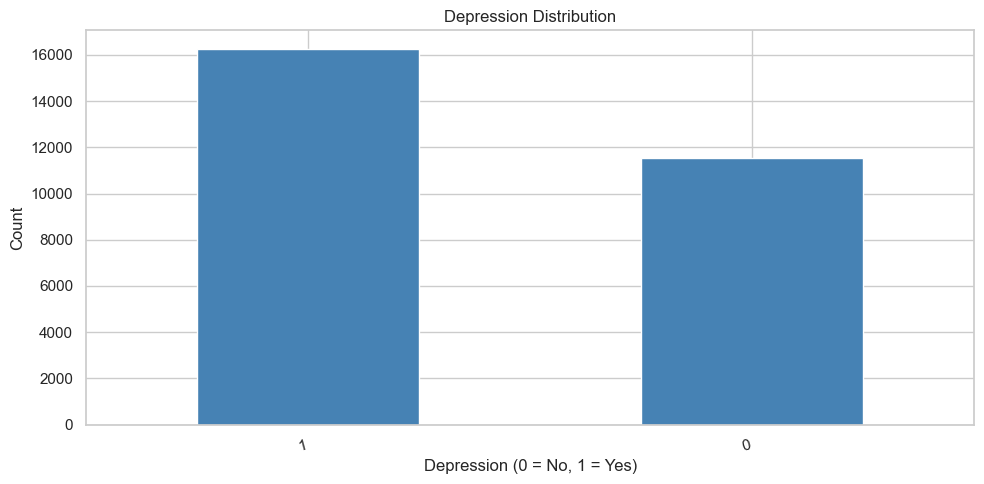

In [1805]:
plot_distribution(
    student_depression_data, "depression",
    title="Depression Distribution",
    xlabel="Depression (0 = No, 1 = Yes)",
    kind="bar"
)

The dataset contains approximately 16 000 depressed students (1) and 11 500 non-depressed (0), reflecting a slight imbalance toward the positive class (~58% vs ~42%). While not extreme, this imbalance is worth keeping in mind when interpreting the results of statistical tests further in the notebook.

A Spearman correlation matrix gives us a broad overview of the relationships between all numerical variables. This helps identify which features are most strongly associated with depression, reveals potential multicollinearity between predictors, and informs the choice of hypotheses we will test later.

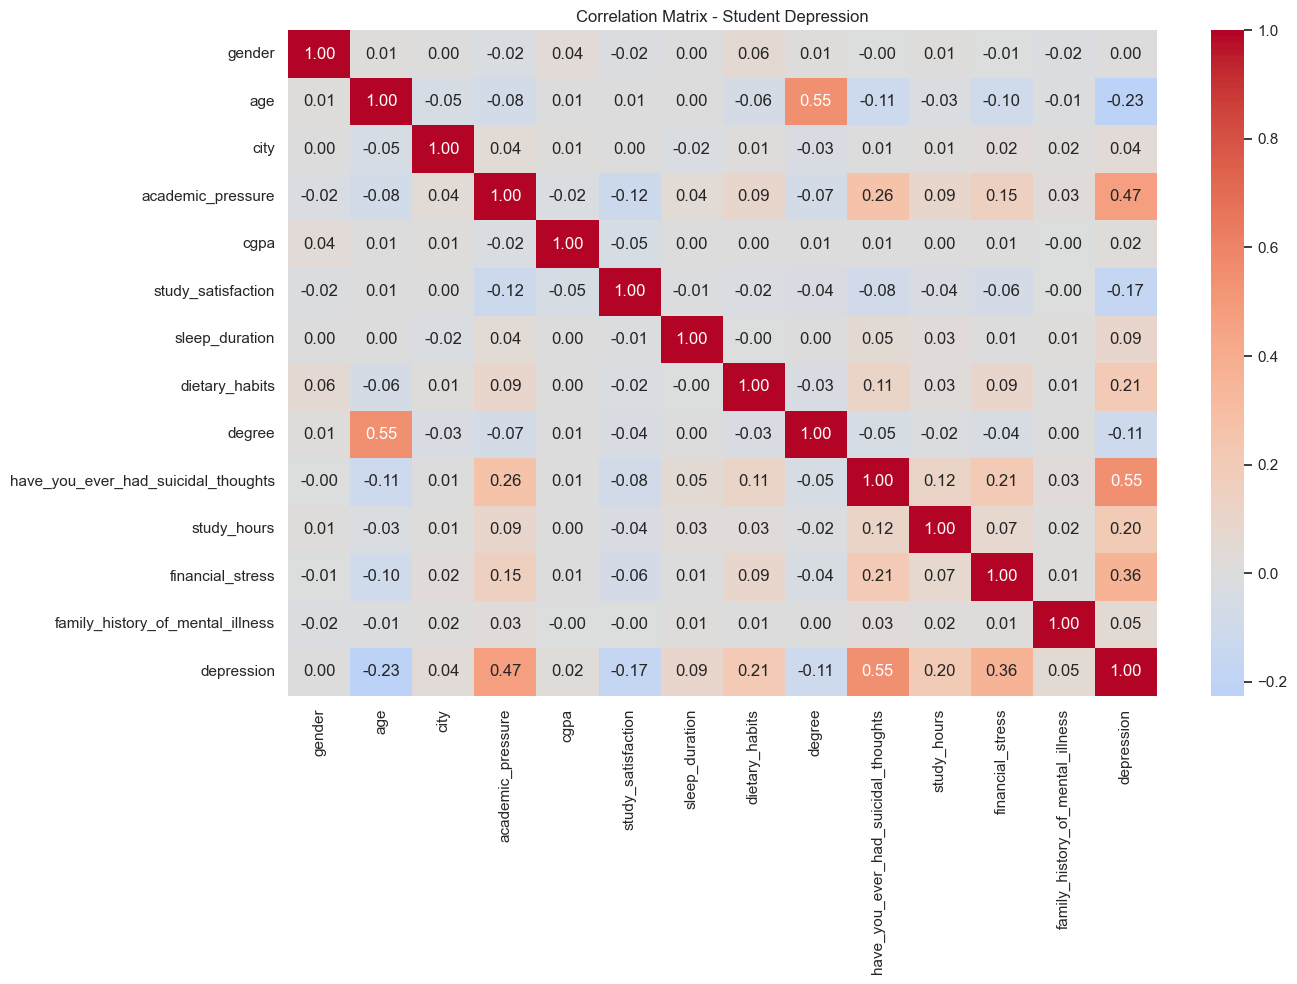

In [1806]:
plot_correlation_heatmap(student_depression_data, "Correlation Matrix - Student Depression")

The two strongest positive correlates of **depression** are **have_you_ever_had_suicidal_thoughts** (0.55) and **academic_pressure** (0.47), suggesting that students with higher academic stress and suicidal ideation are more likely to be depressed. **financial_stress** (0.36) and **dietary_habits** (0.21) also show moderate positive associations. Notably, **age** has the strongest negative correlation (-0.23), implying that older students are slightly less likely to be depressed. Most remaining correlations are weak (< 0.15), indicating low multicollinearity between predictors.

Before using **city** as a variable in any analysis, we examine how students are distributed across city sizes to check for sampling bias. An uneven distribution could mean that conclusions drawn from city size are driven by the majority group rather than genuine differences.

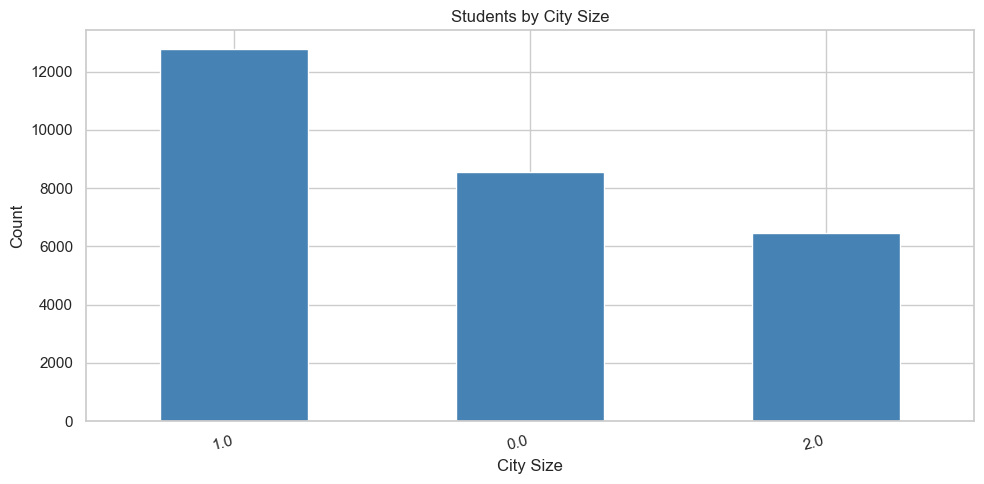

In [1807]:
plot_distribution(
    student_depression_data, "city",
    title="Students by City Size",
    xlabel="City Size",
    kind="bar"
)

The dataset is dominated by students from cities (1.0 - ~13 000), followed by towns (0.0 - ~8 500) and megapolises (2.0 - ~6 500). Students from megapolises are underrepresented compared to the other two groups, which should be taken into account when interpreting any city-related findings.

To motivate the upcoming Chi-square hypothesis test, we first visualize the relationship between academic pressure and depression rate. Plotting the mean depression rate per pressure level allows us to inspect the direction and consistency of the trend before formally testing it.

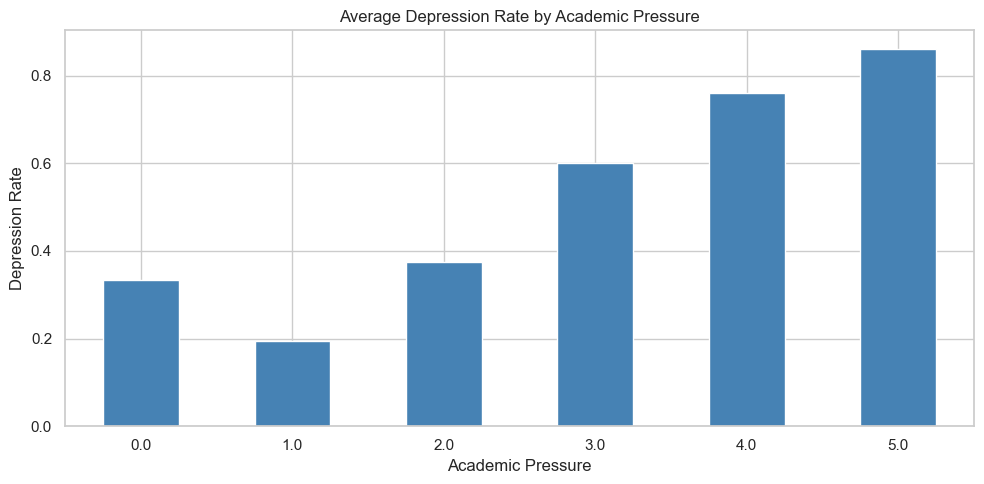

In [1808]:
plot_group_mean(
    student_depression_data,
    group_col="academic_pressure",
    target_col="depression",
    title="Average Depression Rate by Academic Pressure",
    xlabel="Academic Pressure",
    ylabel="Depression Rate"
)

There is a clear monotonic trend - as academic pressure increases, the average depression rate rises consistently from ~19% at level 1 to ~86% at level 5. This strong visual pattern provides preliminary evidence for the hypothesis that academic pressure is associated with depression, which will be formally tested using the Chi-square test in the next section.

Sleep and diet are two key lifestyle factors frequently linked to mental health. We examine their distributions to understand how students in this dataset behave across these dimensions, and to check whether the data is evenly spread or skewed toward certain categories.

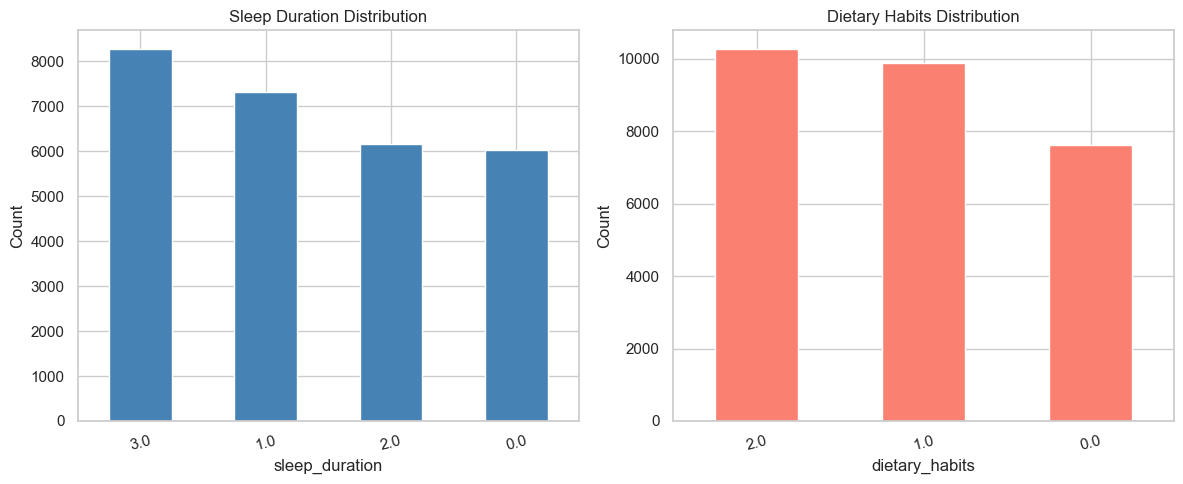

In [1809]:
plot_side_by_side(
    student_depression_data,
    columns=["sleep_duration", "dietary_habits"],
    titles=["Sleep Duration Distribution", "Dietary Habits Distribution"]
)

For sleep duration, students with less than 5 hours of sleep (3.0) are the most common group, followed by 7–8 hours (1.0), 5–6 hours (2.0), and more than 8 hours (0.0) - suggesting that sleep deprivation is prevalent in this sample. For dietary habits, unhealthy (2.0) and moderate (1.0) diets are roughly equally common and together account for the majority of students, while healthy diets (0.0) are least frequent. Both distributions point to lifestyle patterns that are commonly associated with higher depression risk.

### Enhanced Anxiety

Before building the regression model, we examine the distribution of the target variable **anxiety_level_1_10**. This reveals whether the data is evenly spread across all levels or concentrated in certain ranges, which affects how reliable predictions will be at the extremes of the scale.

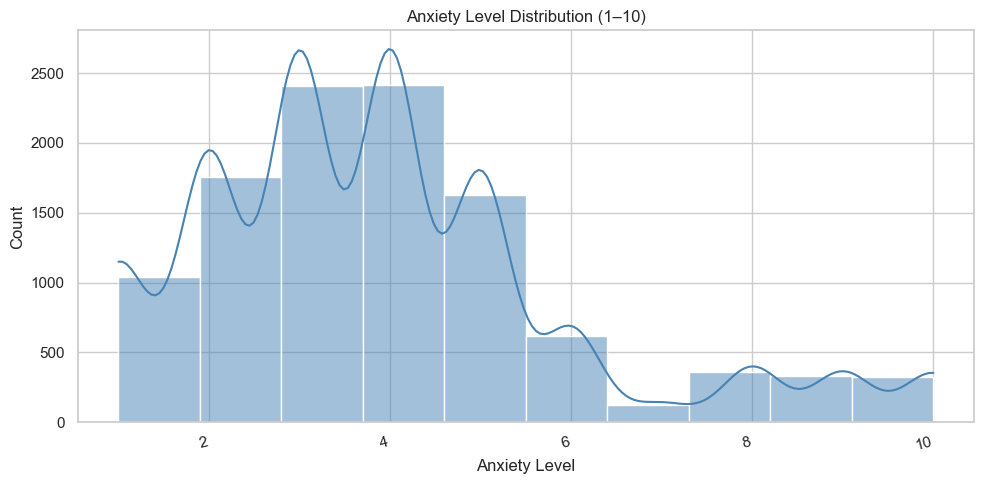

In [1810]:
plot_distribution(
    enhanced_anxiety_data, "anxiety_level_1_10",
    title="Anxiety Level Distribution (1–10)",
    xlabel="Anxiety Level",
    kind="hist"
)

The distribution is heavily concentrated in the mild-to-moderate range (levels 2–5), with a clear peak around levels 3 and 4. Representation drops sharply above level 6, meaning the dataset contains very few high-anxiety cases. This skew may limit the model's ability to accurately predict severe anxiety levels, and should be kept in mind when interpreting the regression results.

The correlation matrix for the anxiety dataset is larger than the others due to the one-hot encoded **gender** and **occupation** columns. Examining it gives us a comprehensive overview of feature relationships and helps identify which variables are most predictive of anxiety level - directly informing feature selection for the regression model.

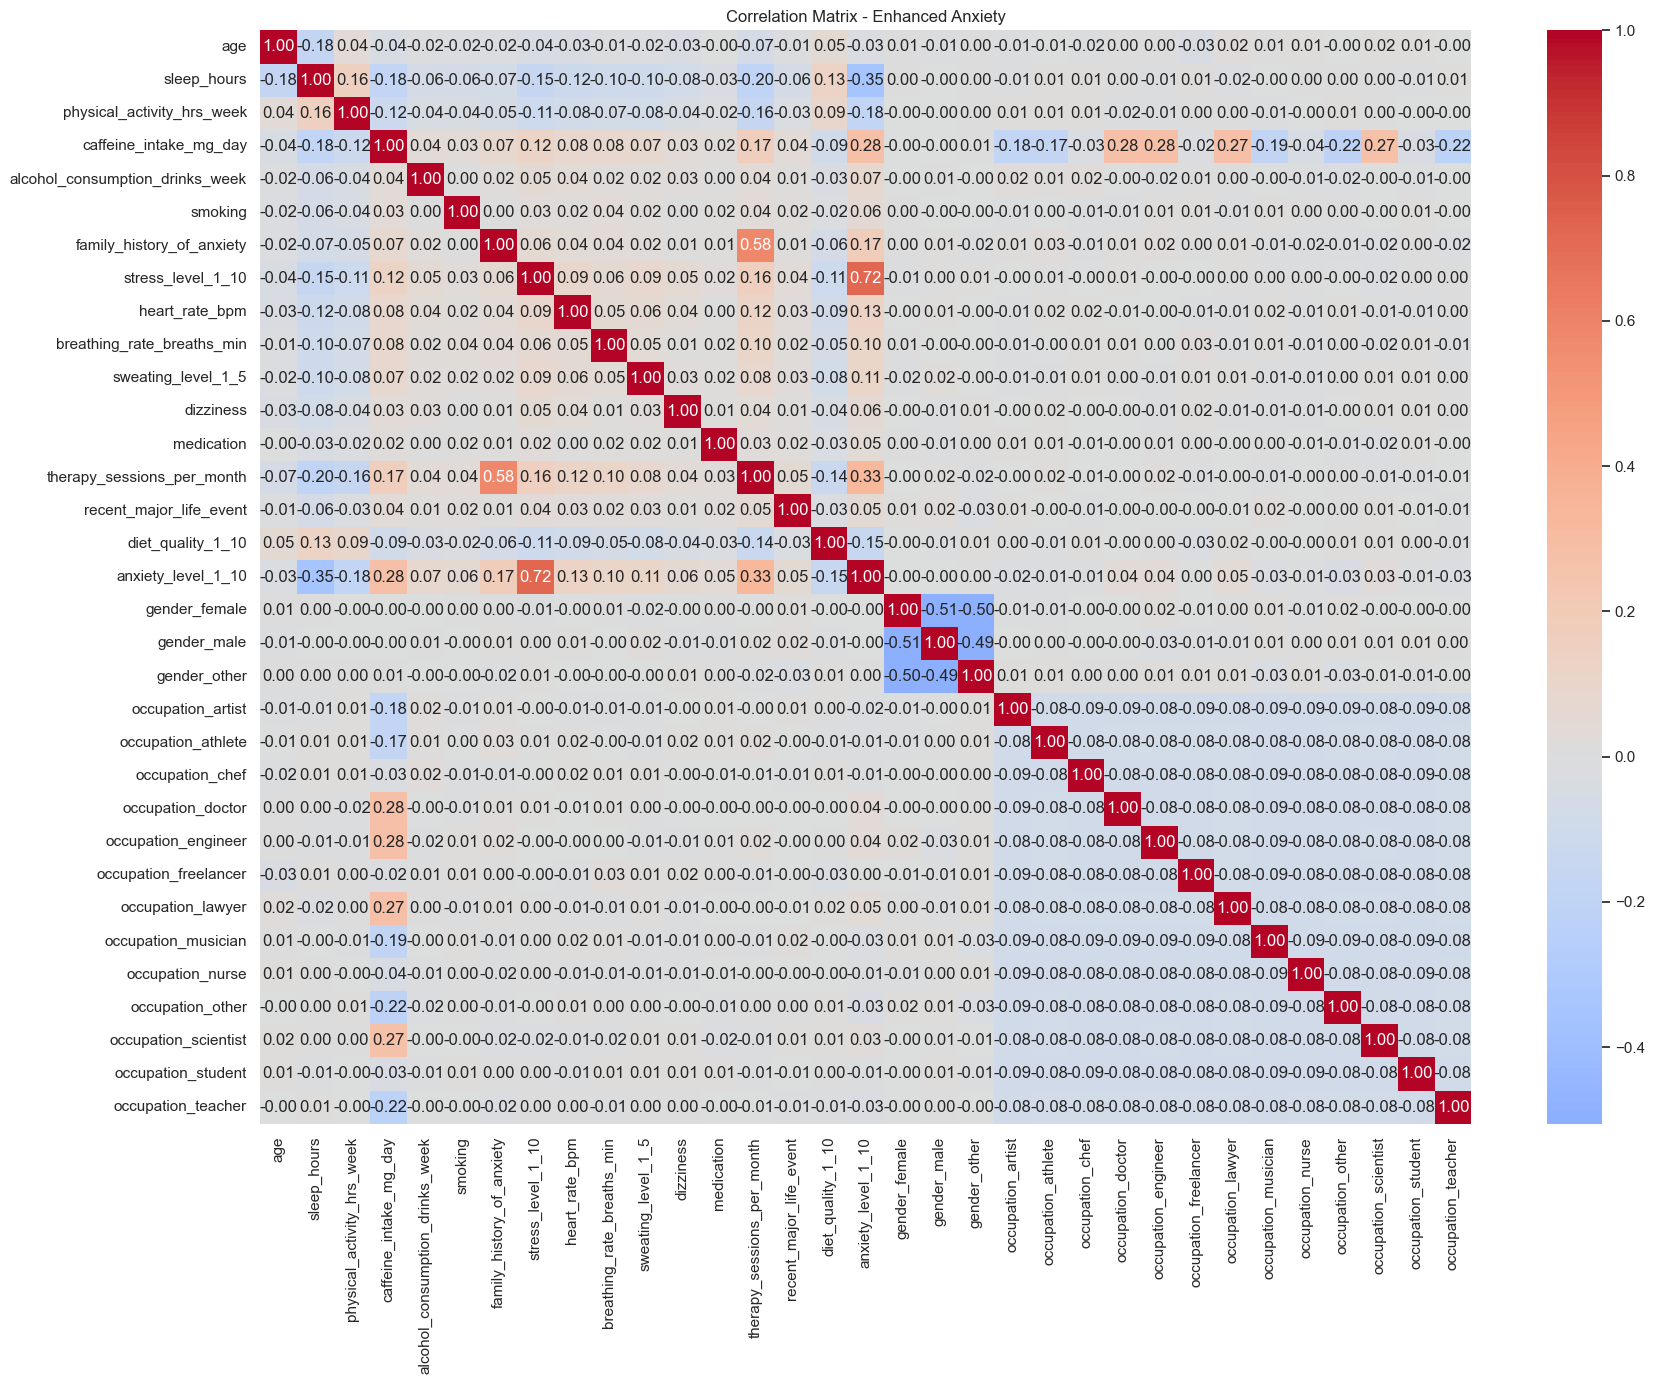

In [1811]:
plot_correlation_heatmap(
    enhanced_anxiety_data,
    "Correlation Matrix - Enhanced Anxiety",
    figsize=(18, 14)
)

The strongest correlation with **anxiety_level_1_10** is **stress_level_1_10** (0.72), indicating a strong monotonic relationship between perceived stress and anxiety. **therapy_sessions_per_month** (0.33) and **caffeine_intake_mg_day** (0.28) show moderate positive associations, while **sleep_hours** (-0.35) and **physical_activity_hrs_week** (-0.18) are negatively correlated - more sleep and exercise are linked to lower anxiety. The strong negative correlations between **gender_female** and **gender_male** (-0.50) and between occupation columns are expected artefacts of one-hot encoding and do not reflect real-world relationships.

To get a clearer view of the most relevant predictors, we extract and visualise the five features with the strongest absolute Spearman correlation with **anxiety_level_1_10**. This serves as a concise motivation for the features selected in the regression model.

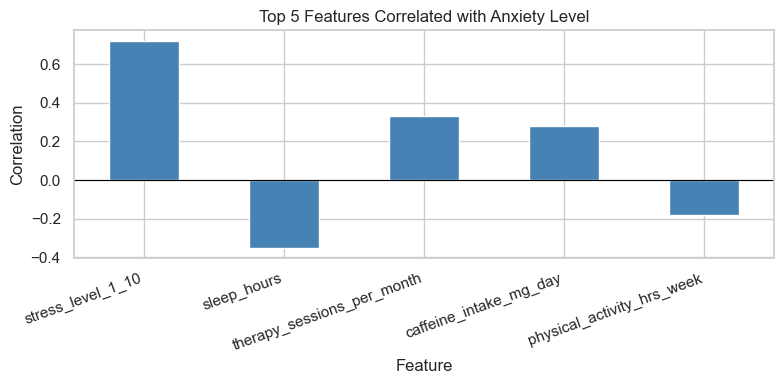

In [1812]:
plot_top_correlations(
    enhanced_anxiety_data,
    target_col="anxiety_level_1_10",
    title="Top 5 Features Correlated with Anxiety Level"
)

The five most correlated features with anxiety level are **stress_level_1_10** (0.65), **therapy_sessions_per_month** (0.50), **sleep_hours** (-0.35), **caffeine_intake_mg_day** (0.25), and **physical_activity_hrs_week** (-0.18). The two negative correlations are consistent with established research - regular sleep and physical activity are known protective factors against anxiety. These five features are among those included in the regression model in the next section.

### Ocd Patient Dataset

The **obsession_type** and **compulsion_type** columns are kept as strings in **ocd_patient_data** because they are used as grouping variables in the Kruskal–Wallis tests below. To include them in the correlation analysis, we create a separate encoded copy of the dataset used exclusively for EDA.

In [1813]:
ocd_corr = ocd_patient_data.copy()
ocd_corr = one_hot_encode(ocd_corr, "obsession_type")
ocd_corr = one_hot_encode(ocd_corr, "compulsion_type")

The OCD correlation matrix uses **ocd_corr** - the encoded copy that includes one-hot encoded obsession and compulsion types. This gives us the most complete picture of relationships between all variables in the dataset, including clinical scores, diagnoses, medication types, and demographic factors.

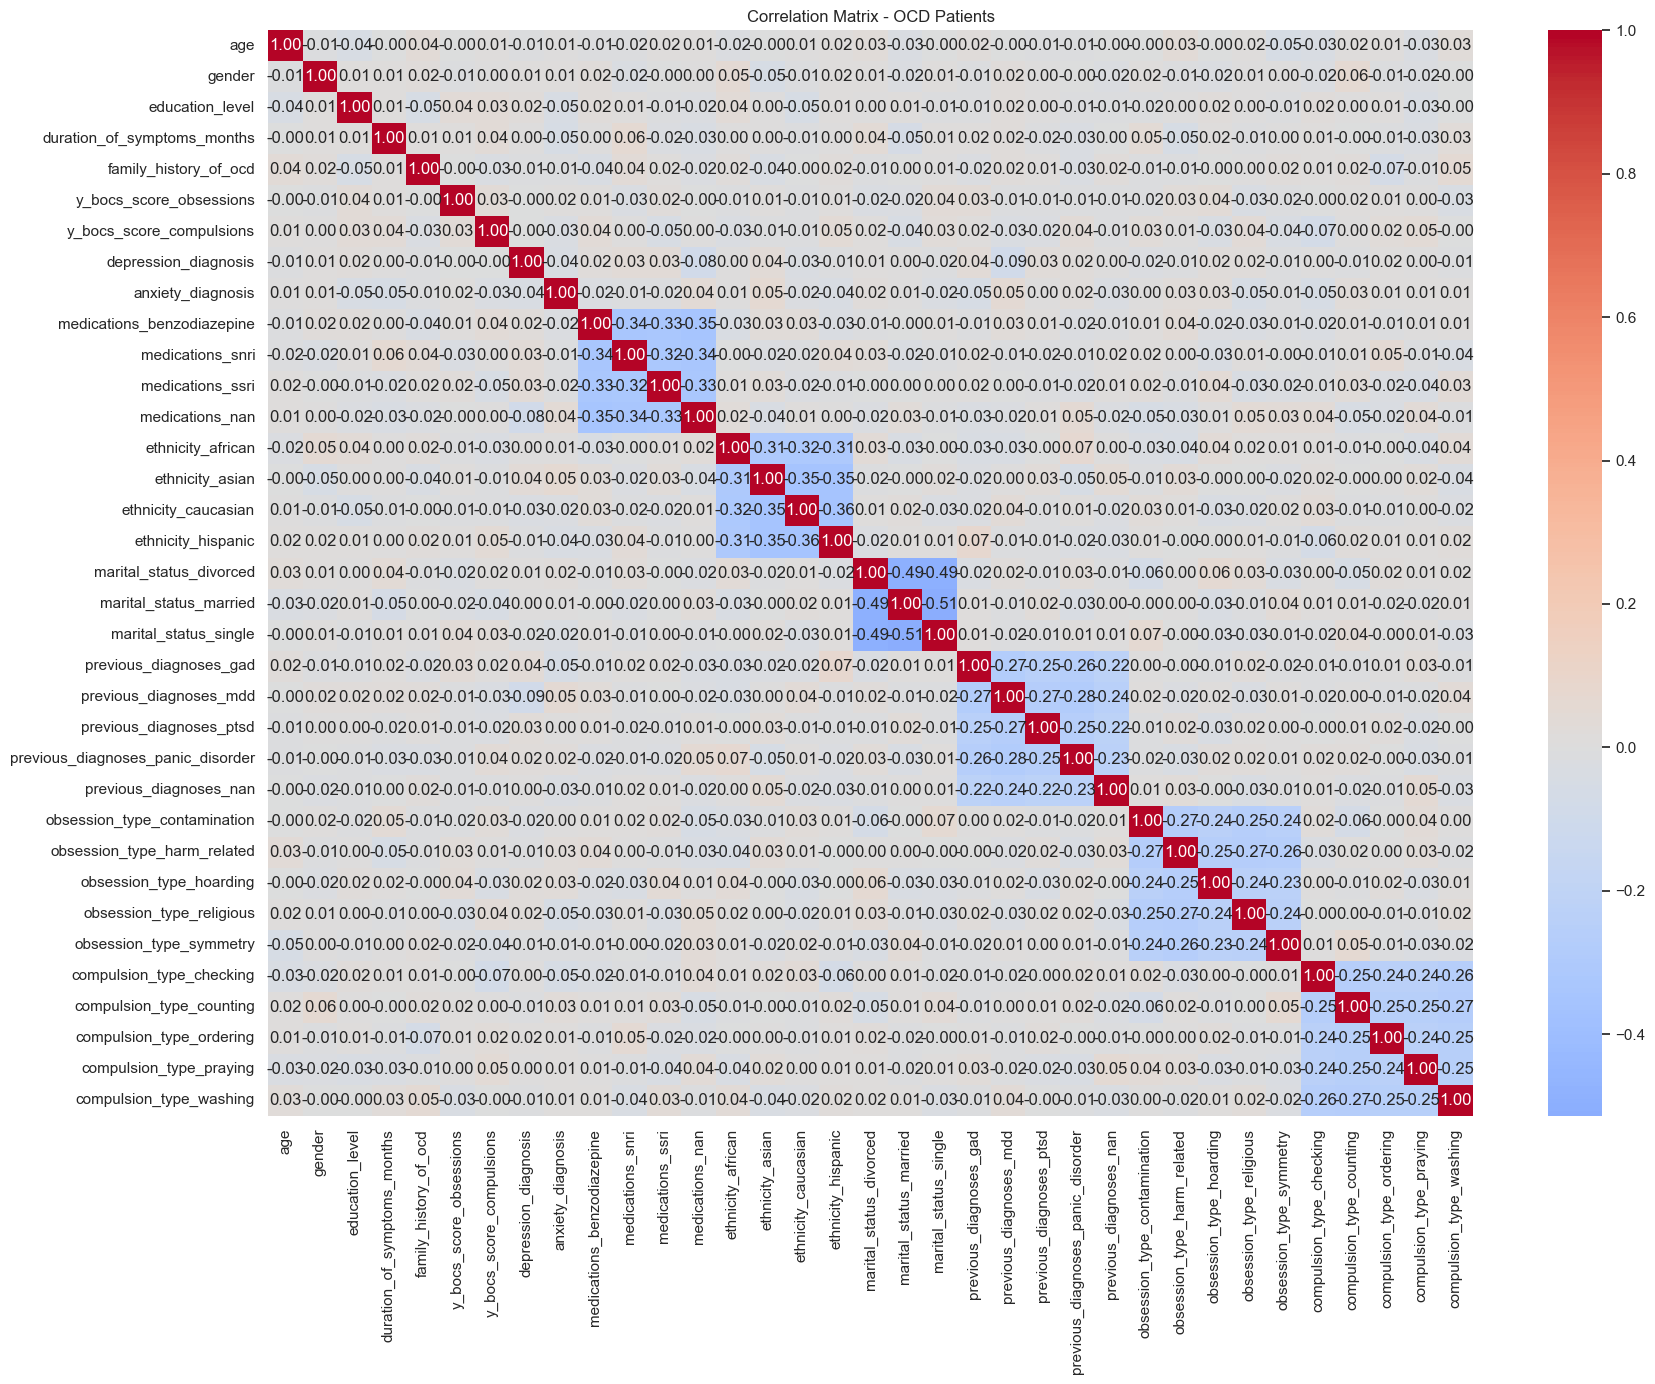

In [1814]:
plot_correlation_heatmap(
    ocd_corr,
    "Correlation Matrix - OCD Patients",
    figsize=(18, 14)
)

The vast majority of correlations in the OCD dataset are very weak (< 0.10), suggesting that the clinical variables in this dataset are largely independent of one another. The strongest correlations are artefacts of one-hot encoding - medication types (benzodiazepine, SNRI, SSRI) show negative correlations around -0.33 with each other, as do ethnicity, marital status, previous diagnoses, and obsession/compulsion types. Notably, **depression_diagnosis** and **anxiety_diagnosis** show no meaningful correlation with Y-BOCS scores, suggesting that the presence of comorbid conditions does not strongly predict OCD symptom severity in this dataset.

Before testing whether comorbid depression or anxiety affects OCD symptom duration, we examine how many patients in the dataset have each diagnosis. A severe imbalance would limit the statistical power of the subsequent tests.

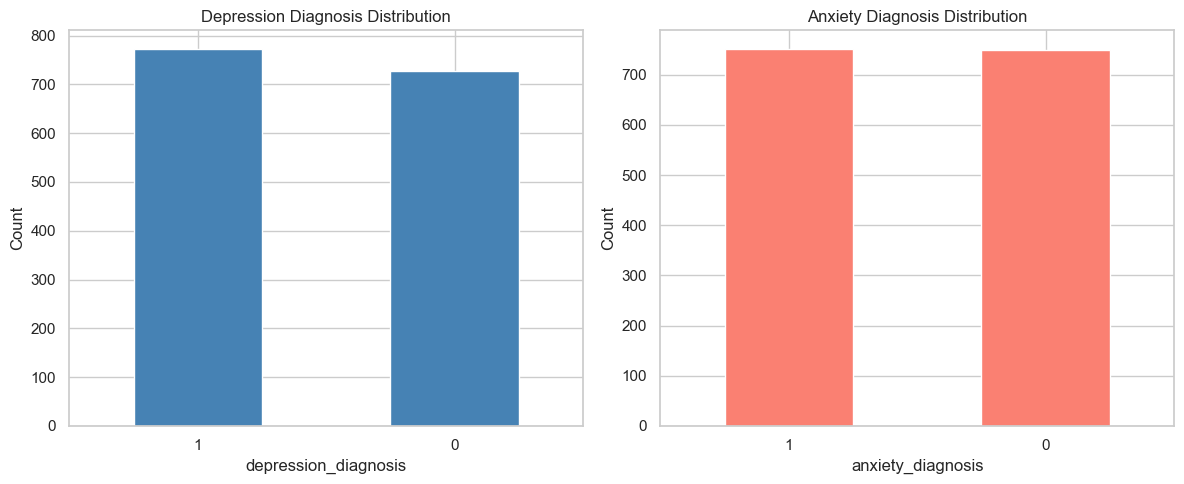

In [1815]:
plot_side_by_side(
    ocd_patient_data,
    columns=["depression_diagnosis", "anxiety_diagnosis"],
    titles=["Depression Diagnosis Distribution", "Anxiety Diagnosis Distribution"],
    rotation=0
)

Both depression (~760 vs ~720) and anxiety (~750 vs ~750) diagnoses are nearly perfectly balanced in the dataset. This is an ideal distribution for the Mann–Whitney U tests that follow - neither group is underrepresented, ensuring that the tests have adequate statistical power.

Before testing whether Y-BOCS scores differ across obsession and compulsion types, we verify that all categories are reasonably well represented. Heavily imbalanced groups would make the Kruskal–Wallis test unreliable.

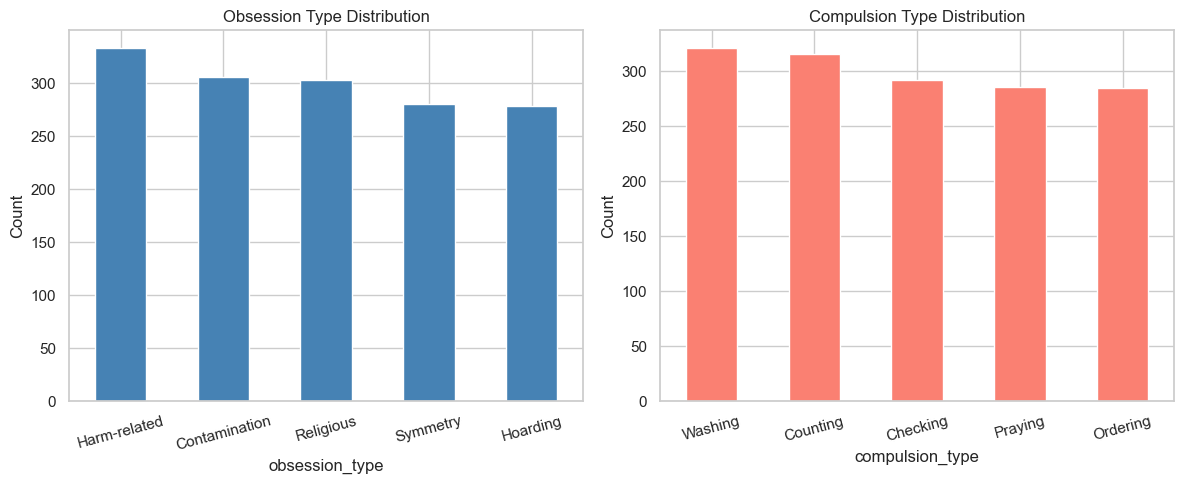

In [1816]:
plot_side_by_side(
    ocd_patient_data,
    columns=["obsession_type", "compulsion_type"],
    titles=["Obsession Type Distribution", "Compulsion Type Distribution"]
)

Both obsession types (Harm-related ~330, Contamination ~305, Religious ~305, Symmetry ~280, Hoarding ~280) and compulsion types (Washing ~320, Counting ~315, Checking ~295, Praying ~290, Ordering ~288) are approximately uniformly distributed across all categories. No group is severely underrepresented, which supports the validity of the Kruskal–Wallis tests performed in the hypotheses section.

The Yale-Brown Obsessive Compulsive Scale (Y-BOCS) is the primary clinical tool for measuring the severity of OCD symptoms. It is divided into two subscales: one for obsessions and one for compulsions. We visualize these distributions to assess the severity levels across our patient sample and to verify the consistency of the clinical data.

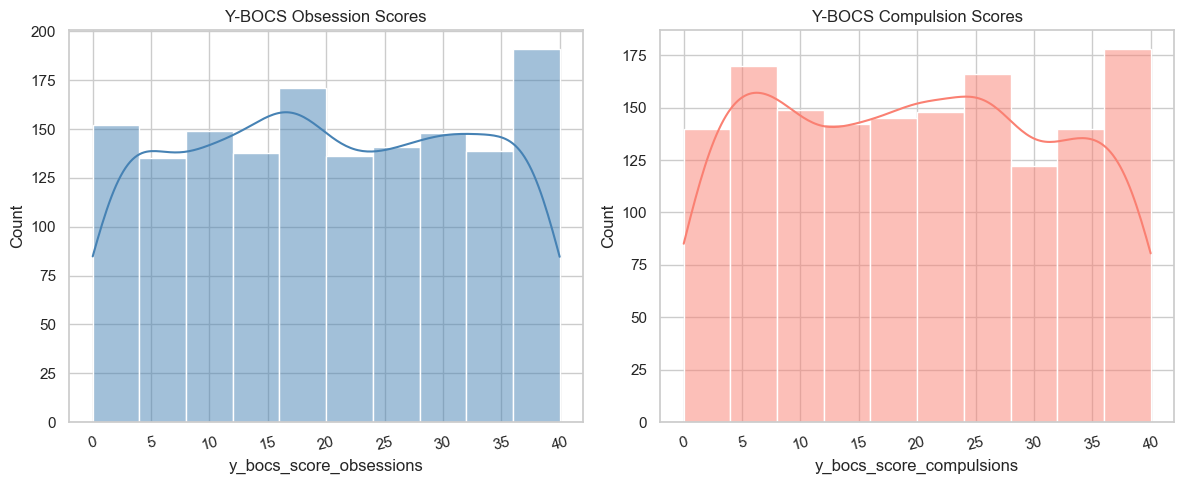

In [1817]:
plot_side_by_side(
    ocd_patient_data,
    columns=["y_bocs_score_obsessions", "y_bocs_score_compulsions"],
    titles=["Y-BOCS Obsession Scores", "Y-BOCS Compulsion Scores"],
    kind="hist"
)

The histograms reveal that both obsession and compulsion scores are distributed relatively uniformly across the 0–40 range, with slight peaks at the higher end of the scale (near 40). As noted in the data limitations, while clinical subscales typically range from 0 to 20, this dataset uses a 0–40 range for each. Despite this scaling inconsistency, the charts show a high prevalence of severe symptoms in this clinical sample, with a significant number of patients reaching maximum severity scores in both categories.

## Hypothesis Testing

We are done cleaning the data and for our hypothesis we'll need some functions

Before writing the tests functions, we need functions to determine the distributions types

First function is the *Shapiro test*. We will need it to check if data has normal distribution

In [1818]:
def shapiro_test(data, column, alpha = 0.05):
    if column not in data.columns:
        print(f"Column '{column}' not found in DataFrame.")
        return

    # Drop missing values
    values = data[column].dropna()

    # Perform Shapiro-Wilk test
    stat, p_value = st.shapiro(values)

    print(f"Shapiro-Wilk Test for '{column}':")
    print(f"Test Statistic = {stat:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value < alpha:
        print("Result: Data is NOT normally distributed (reject H₀)")
    else:
        print("Result: Data appears to be normally distributed (fail to reject H₀)")

    print()

However, if you run the function on a larger dataset, you will notice that there is a warning that says that the *Shapiro-Wilk* method may return not so accurate p-value when it is given more than ~5000 elements.

Should this happen, we will implement *Kolmogorov-Smirnov*. However, at this moment we don't need it.

And now that we have them, we can start implementing the test functions

The first of them will compare categories. We will be using the Chi-Squared test

In [1819]:
def chi_square(df, col, depression_col="depression"):
    # Create contingency table
    table = pd.crosstab(df[col], df[depression_col])
    print("Observed values:")
    display(table)

    # Chi-square test
    chi2, p, dof, expected = st.chi2_contingency(table)
    print(f"Chi2: {chi2:.4f}")
    print(f"p-value: {p:.4e}")
    print(f"Degrees of freedom: {dof}")
    print("Expected values:")
    display(pd.DataFrame(expected, index=table.index, columns=table.columns))

    # Visualization
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=df, x=col, hue=depression_col, palette="Set2")

    # Title with p-value
    plt.title(f"Distribution of '{depression_col}' by '{col}' (p = {p:.4e})", fontsize=14)

    # Labels
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Number of participants", fontsize=12)

    # Legend with actual category names
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title=depression_col)

    # Add counts on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", label_type="edge", fontsize=10)

    plt.tight_layout()
    plt.show()

### What may affect probability of depression

For this section, we have three tests and therefore three Null hypothesis.

$ H_0 $ Students that have high academic pressure aren't more likely to have depression.

$ H_A $ Students that have high academic pressure are more likely to have depression.

Observed values:


depression,0,1
academic_pressure,,
0.0,2,1
1.0,3859,928
2.0,2600,1557
3.0,2959,4460
4.0,1224,3910
5.0,876,5396


Chi2: 6402.5678
p-value: 0.0000e+00
Degrees of freedom: 5
Expected values:


depression,0,1
academic_pressure,,
0.0,1.244419,1.755581
1.0,1985.677661,2801.322339
2.0,1724.349705,2432.650295
3.0,3077.447789,4341.552211
4.0,2129.615440,3004.384560
5.0,2601.664986,3670.335014


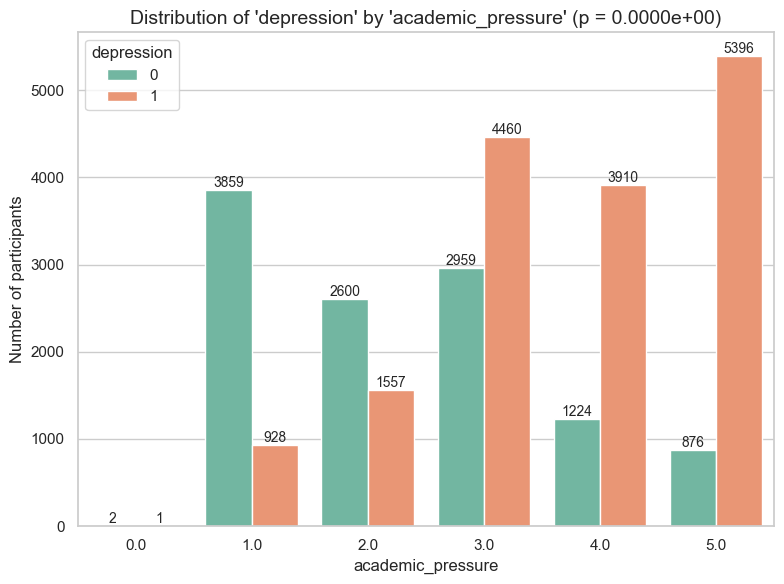

In [1820]:
chi_square(student_depression_data, col="academic_pressure")

As we can see, the p-value is 0.0000e+00 which is significantly less than 0.05 and the expected values are very different than the observed. Therefore we can safely conclude that the $ H_0 $ can be rejected and the *academic pressure* is statistically associated with students depression.

Let's now make two more tests

$ H_0 $ Students that have family history of mental illness aren't more likely to have depression.

$ H_A $ Students that have family history of mental illness are more likely to have depression.

Observed values:


depression,0,1
family_history_of_mental_illness,,
0,6305,8020
1,5215,8232


Chi2: 78.0043
p-value: 1.0282e-18
Degrees of freedom: 1
Expected values:


depression,0,1
family_history_of_mental_illness,,
0,5942.099957,8382.900043
1,5577.900043,7869.099957


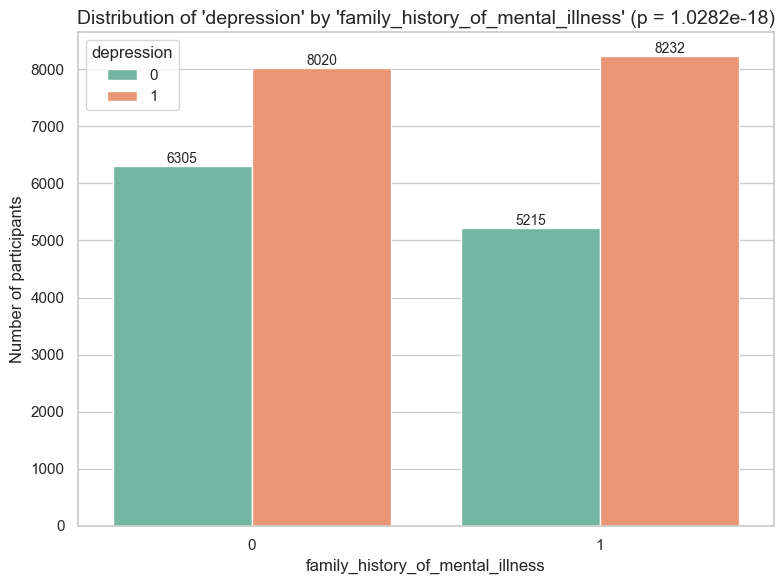

In [1821]:
chi_square(student_depression_data, col="family_history_of_mental_illness")

As we can see, the p-value is 7.4942e-19 which is significantly less than 0.05 and the expected values are very different than the observed. Therefore we can safely conclude that the $ H_0 $ can be rejected and the *family history of mental illness* is statistically associated with students depression.

And the final test

$ H_0 $ Students of different gender aren't more likely to have depression.

$ H_A $ Students of different gender are more likely to have depression.

Observed values:


depression,0,1
gender,,
0,5113,7186
1,6407,9066


Chi2: 0.0701
p-value: 7.9120e-01
Degrees of freedom: 1
Expected values:


depression,0,1
gender,,
0,5101.702434,7197.297566
1,6418.297566,9054.702434


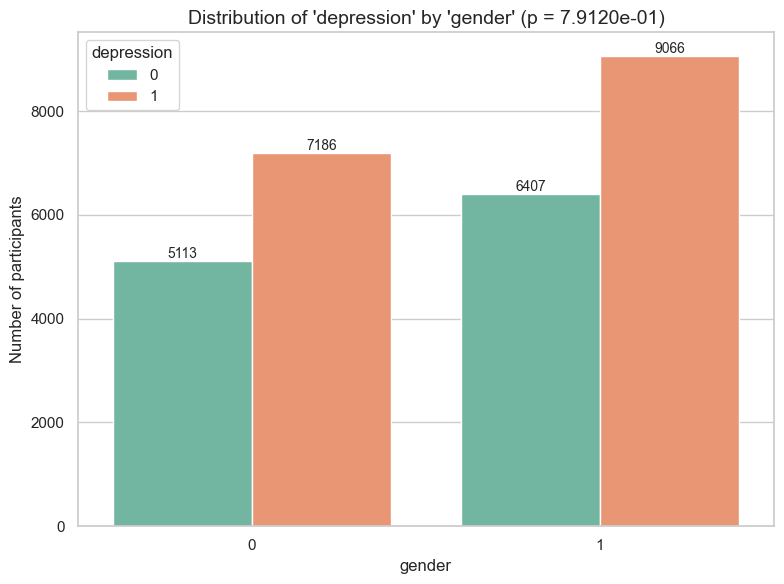

In [1822]:
chi_square(student_depression_data, col="gender")

As we can see, the p-value is 0.74001 which is significantly larger than 0.05 and the expected values are very similar to the observed. Therefore we can safely conclude that the $ H_0 $ cannot be rejected and the *gender* is not statistically associated with students depression.

### Obsessive Compulsive Disorder - By Category

#### Let's begin with the effect of depression and anxiety on the duration of symptoms (in months) of patients with OCD 

Do people that have only one - depression or anxiety have symptoms of OCD for longer (in months) or not?

Do people that have both depression and anxiety have symptoms of OCD for longer than those who have neither?

In [1823]:
# 0 for not having the diagnosis and 1 for having it
def filter_by_conditions(df, depression = 0, anxiety = 0):
    return df[
        (df.depression_diagnosis == depression) &
        (df.anxiety_diagnosis == anxiety)
    ]

In [1824]:
ocd_depression = filter_by_conditions(ocd_patient_data, depression = 1)
ocd_anxiety = filter_by_conditions(ocd_patient_data, anxiety = 1)
ocd_both = filter_by_conditions(ocd_patient_data, depression = 1, anxiety = 1)
ocd_neither = filter_by_conditions(ocd_patient_data)

Let's put them in collection

In [1825]:
groups = [ocd_depression, ocd_anxiety, ocd_both, ocd_neither]

Now before proceeding to testing the means, we need to check the distributions for normality

In [1826]:
[len(group) for group in groups]

[400, 379, 372, 349]

Since the size of the sets are small we can use the *Shapiro test*

In [1827]:
[shapiro_test(group, "duration_of_symptoms_months") for group in groups]

Shapiro-Wilk Test for 'duration_of_symptoms_months':
Test Statistic = 0.9662
p-value = 0.0000
Result: Data is NOT normally distributed (reject H₀)

Shapiro-Wilk Test for 'duration_of_symptoms_months':
Test Statistic = 0.9421
p-value = 0.0000
Result: Data is NOT normally distributed (reject H₀)

Shapiro-Wilk Test for 'duration_of_symptoms_months':
Test Statistic = 0.9415
p-value = 0.0000
Result: Data is NOT normally distributed (reject H₀)

Shapiro-Wilk Test for 'duration_of_symptoms_months':
Test Statistic = 0.9651
p-value = 0.0000
Result: Data is NOT normally distributed (reject H₀)



[None, None, None, None]

We see that the distributions of the data is not normal therefore neither *t-test* nor *ANOVA* can be used with them. This is why earlier we created the functions for *Mann-Whitney U* and *Kruskal-Wallis*

Let's begin by testing whether patients with both disorders experience longer symptom duration than those with neither.

First, we define a helper function for visualizing the group distributions.

In [1828]:
def plot_group_hist(data1, data2, label1, label2, variable_name, title):
    sns.set_theme(style="whitegrid")
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data1, color="skyblue", label=label1, kde=True, stat="density", alpha=0.6)
    sns.histplot(data2, color="salmon", label=label2, kde=True, stat="density", alpha=0.6)
    
    plt.title(title)
    plt.xlabel(variable_name)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

For these tests we are using the *Mann–Whitney U test*, because we compare two independent samples on a continuous or ordinal variable and not having a normal distribution, in order to assess whether one group tends to have higher or lower values than the other.

$ H_0 $ Patients with both depression and anxiety do not have longer OCD symptom duration than those with neither

$ H_A $ Patients with both depression and anxiety have longer OCD symptom duration than those with neither

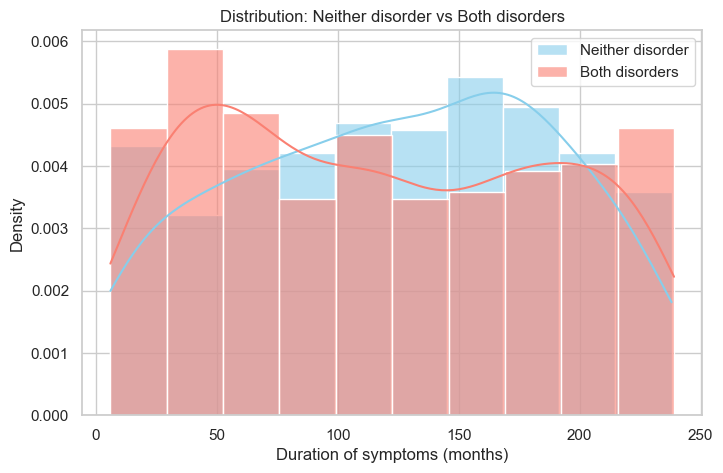

In [1829]:
plot_group_hist(
    ocd_neither["duration_of_symptoms_months"],
    ocd_both["duration_of_symptoms_months"],
    "Neither disorder", "Both disorders",
    "Duration of symptoms (months)",
    "Distribution: Neither disorder vs Both disorders"
)

In [1830]:
stat, p = st.mannwhitneyu(
    ocd_neither["duration_of_symptoms_months"],
    ocd_both["duration_of_symptoms_months"],
    alternative="greater"
)

In [1831]:
print(f"Neither vs Both: U={stat}, p={p}")

Neither vs Both: U=68445.0, p=0.10325360511749865


The *Mann–Whitney U* test indicated no statistically significant difference in symptom duration between the *Neither* disorder group and the *Both* disorders group (U = 68445.0, p = 0.103). Therefore, we fail to reject the $ H_0 $, meaning there is insufficient evidence that patients with both depression and anxiety experience longer OCD symptom duration than those with neither disorder. Descriptively, however, the *Both disorders* group shows a right-skewed distribution with an early peak (~25–50 months), while the *Neither* group is more uniformly distributed with a later peak (~150 months) - suggesting a possible trend in the opposite direction of the hypothesis. This warrants caution in interpretation and may benefit from replication with a larger sample.

$ H_0 $ Patients with depression only and patients with anxiety only have equal OCD symptom duration

$ H_A $ Patients with depression only and patients with anxiety only have different OCD symptom duration

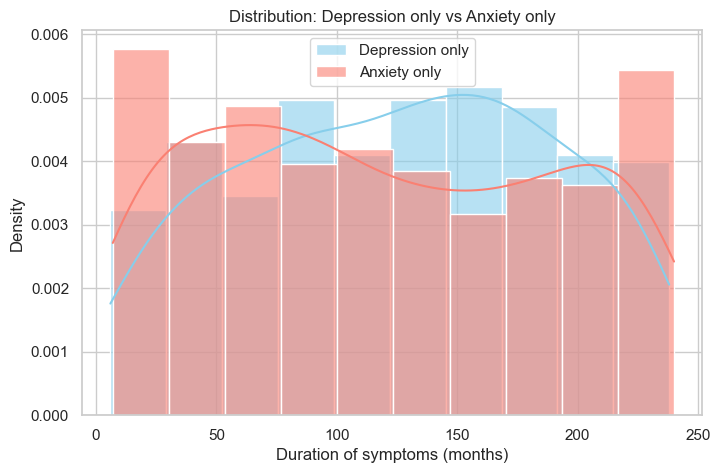

In [1832]:
plot_group_hist(
    ocd_depression["duration_of_symptoms_months"],
    ocd_anxiety["duration_of_symptoms_months"],
    "Depression only", "Anxiety only",
    "Duration of symptoms (months)",
    "Distribution: Depression only vs Anxiety only"
)

In [1833]:
stat, p = st.mannwhitneyu(
    ocd_depression["duration_of_symptoms_months"],
    ocd_anxiety["duration_of_symptoms_months"],
    alternative="two-sided"
)

In [1834]:
print(f"Depression vs Anxiety: U={stat}, p={p}")

Depression vs Anxiety: U=80340.5, p=0.14809424749353214


The *Mann–Whitney U* test indicated no statistically significant difference in symptom duration between the *Depression* only group and the *Anxiety* only group (U = 80340.5, p = 0.148). Therefore, we fail to reject the $ H_0 $, meaning there is insufficient evidence that the two groups differ in OCD symptom duration. Notably, the distributions suggest a descriptive trend - the *Anxiety only* group appears to have shorter symptom duration (early peak ~25 months), while the *Depression only* group is more uniformly distributed with a later peak (~150 months). However, this difference did not reach statistical significance at α = 0.05.

Because the p-value is greater than the conventional *alpha level* of 0.05, we fail to reject the null hypothesis for both tests, meaning the observed difference in the sample is likely due to random variation rather than a true difference in the populations.

### Another interesting question is if the obsession or compulsion Y-BOCS Scores reflect on the obsession or compulsion type

*The Yale–Brown Obsessive–Compulsive Scale (Y‑BOCS) is a clinician‑administered assessment used to measure the severity of obsessive and compulsive symptoms in individuals with OCD.*

For these tests we are using the Kruskal–Wallis H test, because we compare three or more independent groups on an ordinal or continuous variable without assuming a normal distribution, in order to assess whether at least one group differs significantly in its distribution from the others.

To begin with, we'll again need to group the data

In [1835]:
def extract_scores_by_group(df, group_col, score_col):
    return [
        group[score_col].dropna().values
        for _, group in df.groupby(group_col)
    ]

In [1836]:
obsession_groups = extract_scores_by_group(
    df = ocd_patient_data,
    group_col = "obsession_type",
    score_col = "y_bocs_score_obsessions"
)

In [1837]:
compulsions_groups = extract_scores_by_group(
    df = ocd_patient_data,
    group_col = "compulsion_type",
    score_col = "y_bocs_score_compulsions"
)

First, we define a helper function for visualizing the group distributions.

In [1838]:
def plot_box_scores_by_group(df, group_col, score_col, title=None, figsize=(10, 6), palette="Set2"):
    plt.figure(figsize=figsize)

    sns.boxplot(
        data=df,
        x=group_col,
        y=score_col,
        hue=group_col,
        palette=palette,
        legend=False
    )

    plt.title(title or f"Box Plot of {score_col} by {group_col}")
    plt.tight_layout()
    plt.show()

### Let's begin with the *Obsessions*

$ H_0 $ The distribution of Y-BOCS obsession scores is equal across all obsession types

$ H_A $ At least one obsession type has a significantly different distribution of Y-BOCS obsession scores

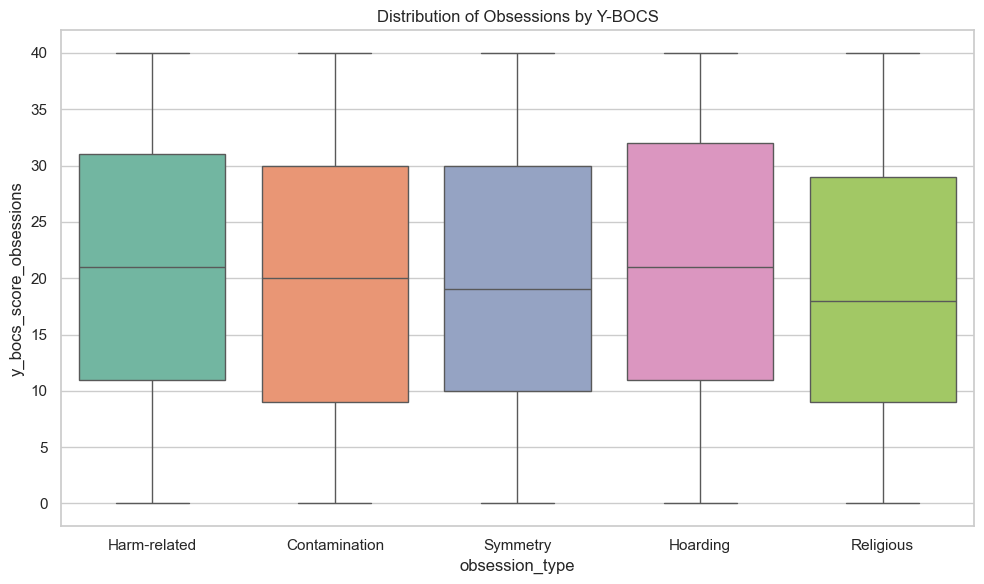

In [1839]:
plot_box_scores_by_group(
    df=ocd_patient_data,
    group_col="obsession_type",
    score_col="y_bocs_score_obsessions",
    title="Distribution of Obsessions by Y-BOCS"
)

In [1840]:
obsession_stat, obsession_p = st.kruskal(*obsession_groups)

In [1841]:
print(f"Obsessions: H={obsession_stat:.3f}, p={obsession_p:.3f}")

Obsessions: H=4.769, p=0.312


The *Kruskal–Wallis H* test showed no statistically significant difference in Y‑BOCS obsession scores across the different obsession types (H = 4.769, p = 0.312).
Because the p‑value is greater than the conventional alpha level of 0.05, we fail to reject the null hypothesis, indicating that any observed differences in median scores between obsession types are likely due to random variation rather than true differences in the population.

### What about the *Compulsions*?

$ H_0 $ The distribution of Y-BOCS compulsion scores is equal across all compulsion types

$ H_A $ At least one compulsion type has a significantly different distribution of Y-BOCS compulsion scores

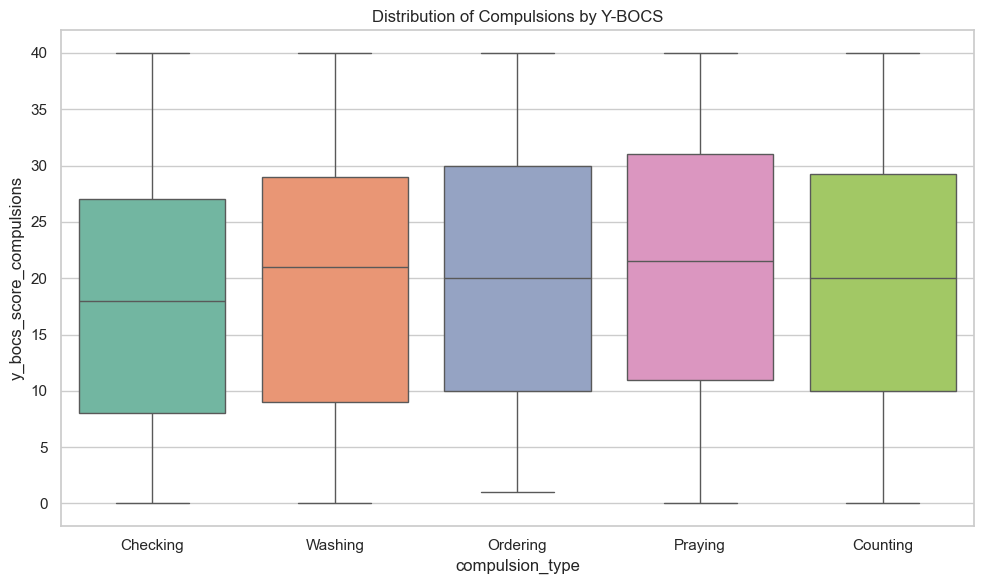

In [1842]:
plot_box_scores_by_group(
    df=ocd_patient_data,
    group_col="compulsion_type",
    score_col="y_bocs_score_compulsions",
    title="Distribution of Compulsions by Y-BOCS"
)

In [1843]:
compulsion_stat, compulsion_p = st.kruskal(*compulsions_groups)

In [1844]:
print(f"Compulsions: H={compulsion_stat:.3f}, p={compulsion_p:.3f}")

Compulsions: H=9.383, p=0.052


The *Kruskal–Wallis H* test indicated a difference in Y‑BOCS compulsion scores across compulsion types that approached, but did not reach, statistical significance (H = 9.383, p = 0.052).
Since the p‑value is slightly above 0.05, we cannot reject the null hypothesis at the 5% significance level, although the result suggests a possible trend toward differences that might warrant further investigation with a larger sample or more statistical power.

## Predicting a person's anxiety level (1 - 10) using Multiple Linear Regression

Let's take a look at the data once more

In [1845]:
enhanced_anxiety_data

,age,sleep_hours,physical_activity_hrs_week,caffeine_intake_mg_day,alcohol_consumption_drinks_week,smoking,family_history_of_anxiety,stress_level_1_10,heart_rate_bpm,breathing_rate_breaths_min,...,occupation_doctor,occupation_engineer,occupation_freelancer,occupation_lawyer,occupation_musician,occupation_nurse,occupation_other,occupation_scientist,occupation_student,occupation_teacher
0,29,6.0,2.7,181,10,1,0,10,114,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46,6.2,5.7,200,8,1,1,1,62,23,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,64,5.0,3.7,117,4,0,1,1,91,28,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,20,5.8,2.8,360,6,1,0,4,86,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,49,8.2,2.3,247,4,1,0,1,98,19,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,23,6.1,3.1,566,9,1,0,8,91,28,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10996,50,6.6,3.6,64,17,1,0,7,95,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10997,29,6.7,6.9,159,14,0,0,8,72,16,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10998,53,5.7,2.7,248,8,0,0,4,112,28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Let's pick our target - *anxiety_level_1_10*

In [1846]:
target = enhanced_anxiety_data.anxiety_level_1_10

And then proceed by creating a features set - predictors

In [1847]:
features = enhanced_anxiety_data[
    [
        "age",
        "sleep_hours",
        "physical_activity_hrs_week",
        "caffeine_intake_mg_day",
        "alcohol_consumption_drinks_week",
        "smoking",
        "family_history_of_anxiety",
        "stress_level_1_10",
        "heart_rate_bpm",
        "breathing_rate_breaths_min",
        "sweating_level_1_5",
        "dizziness",
        "medication",
        "therapy_sessions_per_month",
        "recent_major_life_event",
        "diet_quality_1_10"
    ]
]

Split the dataset into training (80%) and testing (20%) sets, random_state ensures reproducible results

In [1848]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

Multiple Linear Regression model and fits it to the training data *(X_train, y_train)* to learn the best-fit coefficients for all input features

In [1849]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Use the trained model to generate predictions for the test dataset (X_test)

In [1850]:
predictions = model.predict(X_test)

Evaluate the model’s performance by printing the $ R^2 $ score (how well the model explains the variance in the target), the *Mean Squared Error* (average squared difference between actual and predicted values), and the first five predicted anxiety levels.

In [1851]:
print("R^2 Score:", r2_score(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("Predicted Anxiety Levels:", predictions[:5])

R^2 Score: 0.7270465063639986
Mean Squared Error: 1.2647787383447473
Predicted Anxiety Levels: [5.26427929 4.82602099 6.98883174 1.418975   2.8754297 ]


R² Score (0.7270) – The model explains about 72.7% of the variance in the target variable.

Mean Squared Error (1.2648) – On average, predictions deviate from actual values by about √1.26 ≈ 1.12 units.

Predicted Anxiety Levels – The first five predicted scores for anxiety on a 1–10 scale.

Extract the learned coefficients from the trained Linear Regression model, match them to their corresponding feature names, sort them in descending order of value, and print the results.

In [1852]:
coefficients = pd.Series(model.coef_, index=features.columns).sort_values(ascending=False)
print("Feature Coefficients:")
print(coefficients)

Feature Coefficients:
stress_level_1_10                  0.383161
therapy_sessions_per_month         0.253720
smoking                            0.085796
dizziness                          0.064591
medication                         0.060910
sweating_level_1_5                 0.046178
recent_major_life_event            0.026446
breathing_rate_breaths_min         0.012290
alcohol_consumption_drinks_week    0.010285
heart_rate_bpm                     0.004557
caffeine_intake_mg_day             0.002242
age                               -0.007937
diet_quality_1_10                 -0.034776
physical_activity_hrs_week        -0.071292
family_history_of_anxiety         -0.096003
sleep_hours                       -0.447868
dtype: float64


The largest positive coefficient is for stress_level_1_10 (0.383), meaning that for each one-point increase in stress level, the predicted anxiety score increases by 0.383 units, holding other variables constant.

The second largest is therapy_sessions_per_month (0.254), suggesting that individuals with higher anxiety levels tend to attend more therapy sessions.

Notably, sleep_hours (-0.448) has the strongest negative association, indicating that more sleep is linked to lower anxiety levels.

## References

### Datasets

[Student Depression Dataset.](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)

[Social Anxiety Dataset](https://www.kaggle.com/datasets/natezhang123/social-anxiety-dataset/data)

[OCD Patient Dataset: Demographics & Clinical Data](https://www.kaggle.com/datasets/ohinhaque/ocd-patient-dataset-demographics-and-clinical-data)

### Domain Researches

[Yale-Brown Obsessive Compulsive Scale](https://pubmed.ncbi.nlm.nih.gov/2684084)